## Introduction: Connecting Cross-Validation to Regularization

In the **Regularization** chapter, we learned about Ridge, Lasso, and Elastic Net regression and how the regularization strength (alpha) controls the trade-off between bias and variance. We saw that:

- **Small alpha**: Less regularization → higher risk of overfitting
- **Large alpha**: More regularization → higher risk of underfitting
- **Optimal alpha**: Balances bias and variance for best generalization

We observed the *impact* of different alpha values but didn't learn *how to choose* the optimal alpha. That's where cross-validation comes in.

In the previous two notebooks, we learned:
1. **Cross-Validation Fundamentals**: Using `cross_val_score` to evaluate models
2. **GridSearchCV**: Automated hyperparameter tuning for any model

Now we'll explore **specialized tools** designed specifically for tuning regularization parameters. These tools are more efficient than GridSearchCV for regularization problems.

### Learning Objectives

By the end of this notebook, you will:
1. Understand why specialized CV tools exist for regularization
2. Use **RidgeCV** to efficiently tune Ridge regression
3. Use **LassoCV** to efficiently tune Lasso regression  
4. Use **ElasticNetCV** to tune both alpha and l1_ratio for Elastic Net
5. Compare these specialized tools with GridSearchCV
6. Choose the right tool for different regularization scenarios

## Setup and Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

%matplotlib inline
plt.style.use('ggplot')
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10, 6

### Generate Regression Data

We'll create a dataset with multiple features, some of which are informative and others are noise. This setup mimics real-world scenarios where regularization is beneficial.

In [2]:
# Generate regression dataset with noise
X, y = make_regression(
    n_samples=500,
    n_features=50,
    n_informative=20,  # Only 20 out of 50 features are useful
    n_targets=1,
    noise=10,
    random_state=42
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of informative features: 20")

Training samples: 400
Test samples: 100
Number of features: 50
Number of informative features: 20


## Baseline: Using GridSearchCV for Ridge Regression

Before introducing the specialized tools, let's see how we would tune Ridge regression using GridSearchCV from the previous notebook.

In [3]:
# Define alpha values to test
alphas = np.logspace(-4, 4, 50)  # 50 values from 0.0001 to 10000

# Use GridSearchCV to find best alpha
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': alphas},
    cv=5,
    scoring='r2',
    return_train_score=True
)

# Fit and time the operation
import time
start_time = time.time()
ridge_grid.fit(X_train_scaled, y_train)
grid_time = time.time() - start_time

print(f"GridSearchCV completed in {grid_time:.3f} seconds")
print(f"Best alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"Best CV score (R²): {ridge_grid.best_score_:.4f}")
print(f"Test score (R²): {ridge_grid.score(X_test_scaled, y_test):.4f}")

GridSearchCV completed in 0.500 seconds
Best alpha: 0.1842
Best CV score (R²): 0.9983
Test score (R²): 0.9984


GridSearchCV works, but it's **not optimized** for regularization. Let's see how the specialized tools compare.

## RidgeCV: Efficient Cross-Validation for Ridge Regression

`RidgeCV` is a specialized version of Ridge regression that **efficiently** performs cross-validation to select the best alpha value.

### Why RidgeCV is More Efficient

Ridge regression has a special mathematical property: the solution can be computed very efficiently for multiple alpha values simultaneously using a technique called **generalized cross-validation (GCV)** or by exploiting the fact that the solutions share computations.

### Key Features of RidgeCV

✅ **Built-in CV**: No need to wrap in GridSearchCV  
✅ **Efficient computation**: Uses optimized algorithms for Ridge  
✅ **Multiple alphas**: Tests many alpha values quickly  
✅ **Automatic selection**: Returns the best alpha  
✅ **Single interface**: Works like regular Ridge after fitting  

### Using RidgeCV

In [4]:
# Initialize RidgeCV with the same alphas
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')

# Fit and time the operation
start_time = time.time()
ridge_cv.fit(X_train_scaled, y_train)
ridgecv_time = time.time() - start_time

print(f"RidgeCV completed in {ridgecv_time:.3f} seconds")
print(f"Best alpha: {ridge_cv.alpha_:.4f}")

# Make predictions
y_train_pred = ridge_cv.predict(X_train_scaled)
y_test_pred = ridge_cv.predict(X_test_scaled)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")

print(f"\nSpeedup: {grid_time/ridgecv_time:.2f}x faster than GridSearchCV")

RidgeCV completed in 0.334 seconds
Best alpha: 0.1842
Train R²: 0.9989
Test R²: 0.9984
Test MSE: 112.6065

Speedup: 1.50x faster than GridSearchCV


### Visualizing Ridge Coefficient Paths

One advantage of RidgeCV is that we can easily visualize how coefficients change with different alpha values.

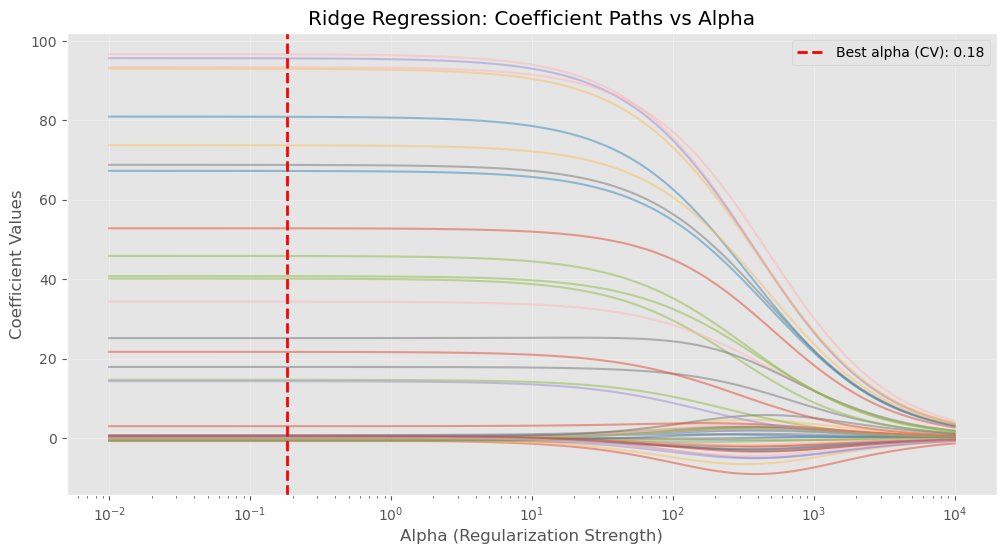

Notice how coefficients shrink toward zero as alpha increases.
The red line shows the optimal alpha chosen by RidgeCV.


In [5]:
# Fit Ridge for multiple alphas to see coefficient paths
alphas_plot = np.logspace(-2, 4, 100)
coefs = []

for alpha in alphas_plot:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

# Plot coefficient paths
plt.figure(figsize=(12, 6))
plt.plot(alphas_plot, coefs, alpha=0.5)
plt.axvline(ridge_cv.alpha_, color='red', linestyle='--', linewidth=2, 
            label=f'Best alpha (CV): {ridge_cv.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Values')
plt.title('Ridge Regression: Coefficient Paths vs Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice how coefficients shrink toward zero as alpha increases.")
print("The red line shows the optimal alpha chosen by RidgeCV.")

## LassoCV: Efficient Cross-Validation for Lasso Regression

`LassoCV` is the cross-validation version of Lasso regression. Unlike Ridge, Lasso can set coefficients **exactly to zero**, performing feature selection.

### Why LassoCV is Important

Lasso uses an iterative algorithm (coordinate descent), which is slower than Ridge's closed-form solution. LassoCV uses **warm starts** (reusing previous solutions) to efficiently test multiple alpha values.

### Key Features of LassoCV

✅ **Built-in CV**: Integrated cross-validation  
✅ **Warm starts**: Efficient computation across alphas  
✅ **Feature selection**: Identifies which features to keep  
✅ **Path computation**: Can compute full regularization path  
✅ **Convergence control**: Adjustable `max_iter` and `tol`  

### Using LassoCV

In [6]:
# Initialize LassoCV
# Note: Lasso requires careful tuning of max_iter and tol
lasso_cv = LassoCV(
    alphas=alphas, 
    cv=5, 
    max_iter=10000,  # Increase if convergence warnings appear
    tol=0.0001,      # Convergence tolerance
    random_state=42
)

# Fit and time the operation
start_time = time.time()
lasso_cv.fit(X_train_scaled, y_train)
lassocv_time = time.time() - start_time

print(f"LassoCV completed in {lassocv_time:.3f} seconds")
print(f"Best alpha: {lasso_cv.alpha_:.4f}")

# Make predictions
y_train_pred = lasso_cv.predict(X_train_scaled)
y_test_pred = lasso_cv.predict(X_test_scaled)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")

# Feature selection: count non-zero coefficients
n_nonzero = np.sum(lasso_cv.coef_ != 0)
print(f"\nFeatures selected: {n_nonzero}/{X_train.shape[1]}")
print(f"Features eliminated: {X_train.shape[1] - n_nonzero}")

LassoCV completed in 0.039 seconds
Best alpha: 0.3907
Train R²: 0.9988
Test R²: 0.9984
Test MSE: 117.9942

Features selected: 32/50
Features eliminated: 18


### Visualizing Lasso Coefficient Paths and Feature Selection

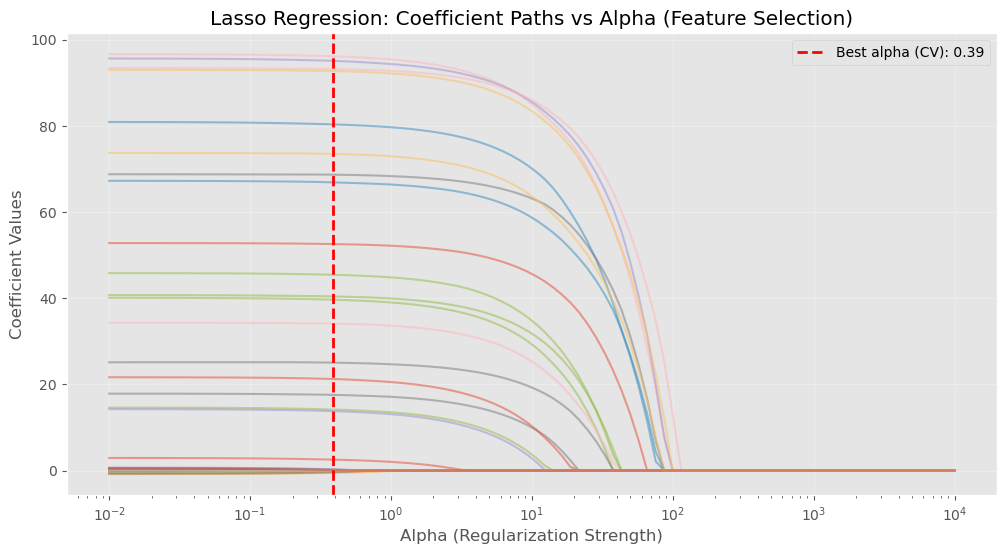

Notice how Lasso coefficients become EXACTLY zero (feature selection).
Ridge only shrinks coefficients toward zero but never eliminates them.


In [7]:
# Fit Lasso for multiple alphas to see coefficient paths
coefs_lasso = []

for alpha in alphas_plot:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(lasso.coef_)

# Plot coefficient paths
plt.figure(figsize=(12, 6))
plt.plot(alphas_plot, coefs_lasso, alpha=0.5)
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', linewidth=2,
            label=f'Best alpha (CV): {lasso_cv.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Values')
plt.title('Lasso Regression: Coefficient Paths vs Alpha (Feature Selection)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice how Lasso coefficients become EXACTLY zero (feature selection).")
print("Ridge only shrinks coefficients toward zero but never eliminates them.")

### Comparing Selected Features

In [8]:
# Compare Ridge vs Lasso coefficients
comparison_df = pd.DataFrame({
    'Feature': range(X_train.shape[1]),
    'Ridge_Coef': ridge_cv.coef_,
    'Lasso_Coef': lasso_cv.coef_,
    'Lasso_Selected': lasso_cv.coef_ != 0
})

print("Top 10 features by absolute coefficient value (Lasso):")
print(comparison_df.reindex(comparison_df['Lasso_Coef'].abs().sort_values(ascending=False).index).head(10))

print(f"\nFeatures with non-zero Lasso coefficients: {n_nonzero}")
print(f"Features with non-zero Ridge coefficients: {np.sum(ridge_cv.coef_ != 0)}")

Top 10 features by absolute coefficient value (Lasso):
    Feature  Ridge_Coef  Lasso_Coef  Lasso_Selected
13       13   96.628353   96.152710            True
16       16   95.611601   95.091756            True
20       20   93.373557   93.153483            True
32       32   92.953043   92.717516            True
15       15   80.890047   80.353362            True
46       46   73.712757   73.509064            True
38       38   68.764065   68.683803            True
29       29   67.242161   66.896368            True
21       21   52.801614   52.583087            True
26       26   45.819338   45.460478            True

Features with non-zero Lasso coefficients: 32
Features with non-zero Ridge coefficients: 50


## ElasticNetCV: Combining L1 and L2 Regularization

`ElasticNetCV` combines Ridge (L2) and Lasso (L1) regularization, controlled by two parameters:
- **alpha**: Overall regularization strength
- **l1_ratio**: Balance between L1 and L2 (0 = pure Ridge, 1 = pure Lasso)

### Why Use Elastic Net?

✅ **Best of both worlds**: Feature selection (L1) + stability (L2)  
✅ **Handles multicollinearity**: Better than Lasso when features are correlated  
✅ **Grouped selection**: Tends to select/eliminate correlated features together  
✅ **More stable**: Less sensitive to feature correlations than Lasso  

### Using ElasticNetCV

In [9]:
# Initialize ElasticNetCV
# It will tune both alpha and l1_ratio
elasticnet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],  # Test different L1/L2 mixes
    cv=5,
    max_iter=10000,
    tol=0.0001,
    random_state=42
)

# Fit and time the operation
start_time = time.time()
elasticnet_cv.fit(X_train_scaled, y_train)
elasticnetcv_time = time.time() - start_time

print(f"ElasticNetCV completed in {elasticnetcv_time:.3f} seconds")
print(f"Best alpha: {elasticnet_cv.alpha_:.4f}")
print(f"Best l1_ratio: {elasticnet_cv.l1_ratio_:.4f}")
print(f"  (0 = pure Ridge, 1 = pure Lasso)")

# Make predictions
y_train_pred = elasticnet_cv.predict(X_train_scaled)
y_test_pred = elasticnet_cv.predict(X_test_scaled)

# Evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")

# Feature selection
n_nonzero_en = np.sum(elasticnet_cv.coef_ != 0)
print(f"\nFeatures selected: {n_nonzero_en}/{X_train.shape[1]}")
print(f"Features eliminated: {X_train.shape[1] - n_nonzero_en}")

ElasticNetCV completed in 0.201 seconds
Best alpha: 0.2683
Best l1_ratio: 0.9900
  (0 = pure Ridge, 1 = pure Lasso)
Train R²: 0.9989
Test R²: 0.9984
Test MSE: 118.0502

Features selected: 37/50
Features eliminated: 13


### Comparing All Three Models

In [10]:
# Create a comprehensive comparison
models_comparison = pd.DataFrame({
    'Model': ['RidgeCV', 'LassoCV', 'ElasticNetCV'],
    'Best Alpha': [ridge_cv.alpha_, lasso_cv.alpha_, elasticnet_cv.alpha_],
    'L1 Ratio': [0.0, 1.0, elasticnet_cv.l1_ratio_],
    'Train R²': [
        r2_score(y_train, ridge_cv.predict(X_train_scaled)),
        r2_score(y_train, lasso_cv.predict(X_train_scaled)),
        r2_score(y_train, elasticnet_cv.predict(X_train_scaled))
    ],
    'Test R²': [
        r2_score(y_test, ridge_cv.predict(X_test_scaled)),
        r2_score(y_test, lasso_cv.predict(X_test_scaled)),
        r2_score(y_test, elasticnet_cv.predict(X_test_scaled))
    ],
    'Test MSE': [
        mean_squared_error(y_test, ridge_cv.predict(X_test_scaled)),
        mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)),
        mean_squared_error(y_test, elasticnet_cv.predict(X_test_scaled))
    ],
    'Features Selected': [
        X_train.shape[1],  # Ridge keeps all features
        np.sum(lasso_cv.coef_ != 0),
        np.sum(elasticnet_cv.coef_ != 0)
    ],
    'Computation Time (s)': [ridgecv_time, lassocv_time, elasticnetcv_time]
})

print("Model Comparison:")
print(models_comparison.to_string(index=False))

Model Comparison:
       Model  Best Alpha  L1 Ratio  Train R²  Test R²   Test MSE  Features Selected  Computation Time (s)
     RidgeCV    0.184207      0.00  0.998909 0.998448 112.606455                 50              0.333731
     LassoCV    0.390694      1.00  0.998841 0.998373 117.994153                 32              0.038877
ElasticNetCV    0.268270      0.99  0.998851 0.998373 118.050176                 37              0.200890


### Visualizing Coefficient Comparison

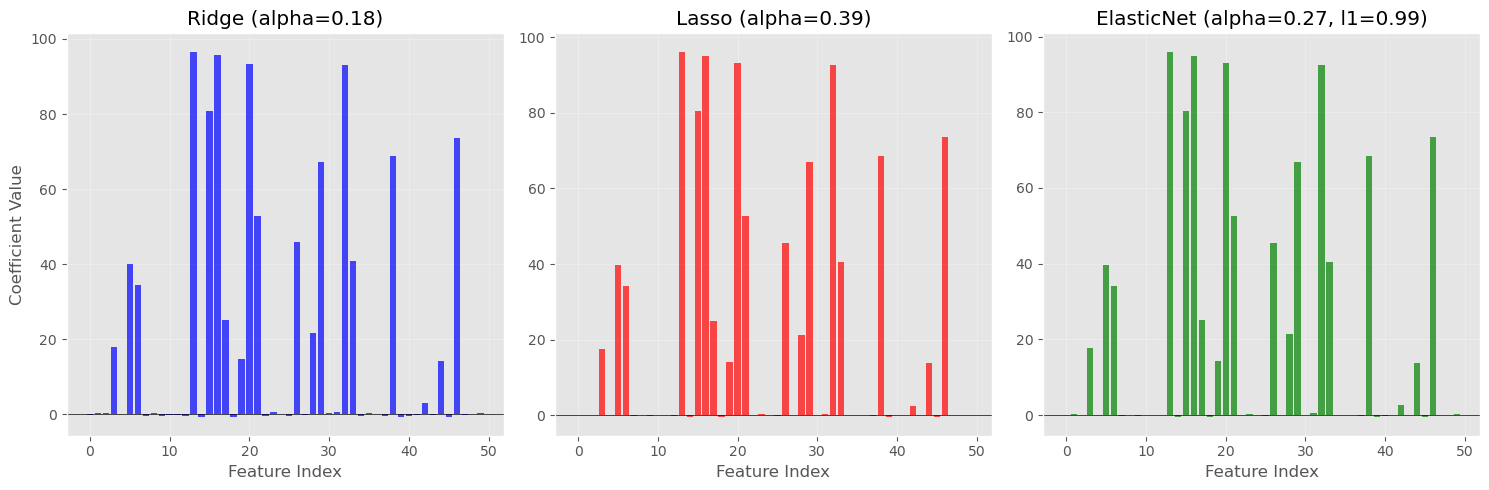

Key Observations:
- Ridge: All coefficients are non-zero (shrunk but not eliminated)
- Lasso: Many coefficients are exactly zero (feature selection)
- ElasticNet: Intermediate behavior, balance between Ridge and Lasso


In [11]:
# Compare coefficients across all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ridge coefficients
axes[0].bar(range(len(ridge_cv.coef_)), ridge_cv.coef_, alpha=0.7, color='blue')
axes[0].set_title(f'Ridge (alpha={ridge_cv.alpha_:.2f})')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('Coefficient Value')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Lasso coefficients
axes[1].bar(range(len(lasso_cv.coef_)), lasso_cv.coef_, alpha=0.7, color='red')
axes[1].set_title(f'Lasso (alpha={lasso_cv.alpha_:.2f})')
axes[1].set_xlabel('Feature Index')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

# ElasticNet coefficients
axes[2].bar(range(len(elasticnet_cv.coef_)), elasticnet_cv.coef_, alpha=0.7, color='green')
axes[2].set_title(f'ElasticNet (alpha={elasticnet_cv.alpha_:.2f}, l1={elasticnet_cv.l1_ratio_:.2f})')
axes[2].set_xlabel('Feature Index')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("- Ridge: All coefficients are non-zero (shrunk but not eliminated)")
print("- Lasso: Many coefficients are exactly zero (feature selection)")
print("- ElasticNet: Intermediate behavior, balance between Ridge and Lasso")

## When to Use Each Tool: Decision Guide

### RidgeCV

**Use when:**
- You want to keep all features
- Features are highly correlated (multicollinearity)
- Interpretability of feature importance is not critical
- You need the fastest computation

**Advantages:**
- Very fast computation
- Stable with correlated features
- No hyperparameters except alpha

**Disadvantages:**
- No feature selection
- All features remain in the model

### LassoCV

**Use when:**
- You want automatic feature selection
- You have many irrelevant features
- Interpretability is important
- Features are relatively independent

**Advantages:**
- Automatic feature selection
- Sparse models (easier to interpret)
- Good when many features are irrelevant

**Disadvantages:**
- Slower than Ridge
- Unstable with highly correlated features
- May arbitrarily select one feature from a correlated group

### ElasticNetCV

**Use when:**
- Features are correlated AND you want feature selection
- You need a balance between Ridge and Lasso
- Lasso is too unstable for your data
- You have groups of correlated features

**Advantages:**
- Combines benefits of Ridge and Lasso
- More stable than Lasso with correlations
- Tends to select/eliminate correlated features together

**Disadvantages:**
- Slowest of the three
- Two hyperparameters to tune (alpha and l1_ratio)
- More complex to interpret

### Quick Reference Table

| Criterion | RidgeCV | LassoCV | ElasticNetCV |
|-----------|---------|---------|--------------|
| **Speed** | ⚡⚡⚡ Fastest | ⚡⚡ Medium | ⚡ Slowest |
| **Feature Selection** | ❌ No | ✅ Yes | ✅ Yes |
| **Correlated Features** | ✅ Handles well | ⚠️ Problematic | ✅ Handles well |
| **Sparse Models** | ❌ No | ✅ Yes | ✅ Yes |
| **Hyperparameters** | 1 (alpha) | 1 (alpha) | 2 (alpha, l1_ratio) |
| **Interpretability** | Medium | High | High |

## Best Practices for Regularization CV Tools

### 1. Always Standardize Features

Regularization is sensitive to feature scales. Always standardize before fitting.

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

### 2. Use Logarithmic Alpha Ranges

Alpha values often span many orders of magnitude. Use `np.logspace`:

```python
alphas = np.logspace(-4, 4, 50)  # From 0.0001 to 10000
```

### 3. Adjust max_iter and tol for Lasso/ElasticNet

If you see convergence warnings, increase `max_iter` or relax `tol`:

```python
lasso_cv = LassoCV(alphas=alphas, max_iter=10000, tol=0.0001)
```

### 4. Use cv Parameter for Custom Cross-Validation

Specify the CV strategy explicitly for better control:

```python
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv = RidgeCV(alphas=alphas, cv=cv)
```

### 5. Check Feature Selection Results

After fitting Lasso or ElasticNet, examine which features were selected:

```python
selected_features = np.where(lasso_cv.coef_ != 0)[0]
print(f"Selected {len(selected_features)} features: {selected_features}")
```

### 6. Compare Multiple Models

Don't rely on just one approach. Compare Ridge, Lasso, and ElasticNet:

```python
# Fit all three and compare test performance
models = [ridge_cv, lasso_cv, elasticnet_cv]
for model in models:
    score = model.score(X_test_scaled, y_test)
    print(f"{model.__class__.__name__}: R² = {score:.4f}")
```

## Summary

In this notebook, we explored **specialized cross-validation tools** for regularized regression, completing our journey through cross-validation techniques.

### Key Concepts

1. **RidgeCV**
   - Efficient CV for Ridge regression (L2 regularization)
   - Fastest of the three methods
   - Keeps all features but shrinks coefficients
   - Best for: multicollinearity, when all features are relevant

2. **LassoCV**
   - Efficient CV for Lasso regression (L1 regularization)
   - Performs automatic feature selection
   - Sets coefficients exactly to zero
   - Best for: sparse models, feature selection, interpretability

3. **ElasticNetCV**
   - Efficient CV for Elastic Net (L1 + L2 regularization)
   - Tunes both alpha and l1_ratio
   - Combines benefits of Ridge and Lasso
   - Best for: correlated features + feature selection

### Comparison with GridSearchCV

| Aspect | GridSearchCV | RidgeCV/LassoCV/ElasticNetCV |
|--------|--------------|------------------------------|
| **Flexibility** | Works with any model | Only for regularized regression |
| **Efficiency** | General-purpose | Optimized for regularization |
| **Speed** | Slower | Faster (up to 5-10x) |
| **Use Case** | Any hyperparameter tuning | Specifically for alpha/l1_ratio |

### Connection to Regularization Chapter

This notebook completes the story started in the **Regularization** chapter:

1. **Regularization Chapter**: Learned about Ridge, Lasso, ElasticNet and *observed* the impact of alpha
2. **CV Fundamentals**: Learned how cross-validation evaluates model performance
3. **GridSearchCV**: Learned general-purpose hyperparameter tuning
4. **This Notebook**: Learned efficient, specialized tools for regularization tuning

### Best Practices Summary

✅ Always standardize features before regularization  
✅ Use `np.logspace` for alpha ranges  
✅ Start with ElasticNetCV if unsure (most flexible)  
✅ Check feature selection results with Lasso/ElasticNet  
✅ Compare all three models before choosing  
✅ Adjust `max_iter` if convergence warnings appear  
✅ Use explicit CV strategy for reproducibility  

### The Complete Cross-Validation Toolkit

You now have three powerful notebooks in your CV toolkit:

1. **Fundamentals**: `cross_val_score`, `cross_val_predict`, CV strategies
2. **General Tuning**: `GridSearchCV`, `RandomizedSearchCV`, threshold tuning  
3. **Regularization**: `RidgeCV`, `LassoCV`, `ElasticNetCV`

Choose the right tool for each problem, and you'll build better, more generalizable models!